In [1514]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches

In [1515]:
#Pre-defined params
# %% create environment, parameters and first simple cells & structures

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = 2.86e9; VRF = 2.000e6 # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({'l_cell': 3.40,'l_bend': 0.40,'l_bendDS': 0.55,'dl_noben': 0.25, 'l_quad': 0.30,
  'l_drift': '(l_cell - 2*l_bend - 2*l_quad)/4.','dl_drift': -0.15, 'dl_trans': 0.00,
  'l_doub':  0.25, 'l_tripl': 3.00, 'l_trips': 0.40})

pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723 } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )

#Add any new variables and structures here
pdr['l_sext']=0.1
pdr['kSF']=0
pdr['kSD']=0

pdr.new('SFDS', xt.Sextupole, length='l_sext',k2='kSF')
pdr.new('SDDS', xt.Sextupole, length='l_sext',k2='kSD')

'SDDS'

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


3.4
3.3999999999999995
4.7


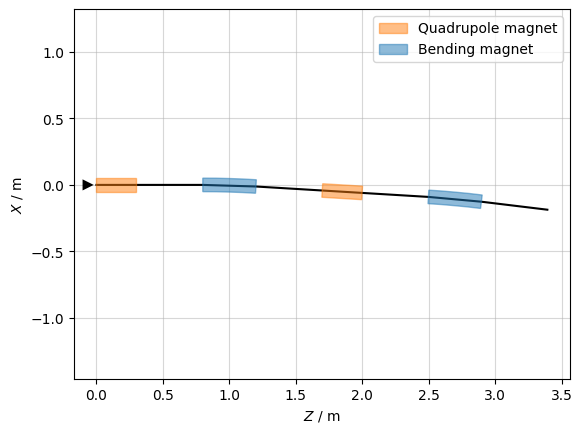

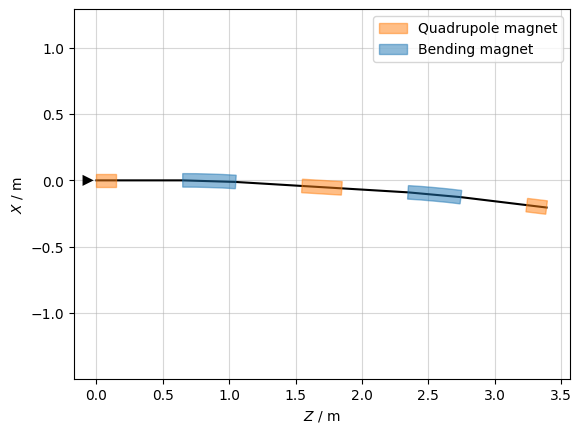

In [1516]:
#Arc design
# just an arc cell
cell_arcS = pdr.new_line( length='l_cell', 
    components =[ 
    pdr.new('QF_cell_arc',    'QFarc',at='0*l_drift + 0.5*l_quad + 0.0*l_bend'),
    pdr.new('Bend1_cell_arc', 'Bend', at='1*l_drift + 1.0*l_quad + 0.5*l_bend'),
    pdr.new('QD_cell_arc',    'QDarc',at='2*l_drift + 1.5*l_quad + 1.0*l_bend'),
    pdr.new('Bend2_cell_arc', 'Bend', at='3*l_drift + 2.0*l_quad + 1.5*l_bend'),
    ])
cell_arcS.survey().plot()
print(cell_arcS.get_length())
cell_arc = pdr.new_line( components = [ 
   pdr.new('QF_cell_arcH1',  'QFarcH' ), pdr.place( 'Drarc' ),
   pdr.new('Bend1_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QD_cell_arcH',   'QDarc' ),  pdr.place( 'Drarc' ),
   pdr.new('Bend2_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QF_cell_arcH2',  'QFarcH' ), 
   ])
cell_arc.survey().plot()
print(cell_arc.get_length())
# triplet starting with 
cell_tr = pdr.new_line(
    components = [
    pdr.new('QF_cell_trH1', 'QFtrH',    at='0*l_trips + 0.25*l_quad + 0.0*l_tripl'),
    pdr.new('QD_cell_tr1',  'QDtr',     at='1*l_trips + 1.00*l_quad + 0.0*l_tripl'),
    pdr.new('Mkr_cell_tr',   xt.Marker, at='1*l_trips + 1.50*l_quad + 0.5*l_tripl'),
    pdr.new('QD_cell_tr2',  'QDtr',     at='1*l_trips + 2.00*l_quad + 1.0*l_tripl'),
    pdr.new('QF_cell_trH2', 'QFtrH',    at='2*l_trips + 2.75*l_quad + 1.0*l_tripl')
    ])

print(cell_tr.get_length())

In [1517]:
#makesextant function
def makesextant ( name, fall ):
    comps = [ ]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.new('Drarc1_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc2_'+ name + str(ind+1), 'Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [ pdr.new('Drarc3_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc4_'+ name + str(ind+1), 'Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-1] = pdr.new('QFAM' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps = comps + [pdr.new('DrarcS1_'+ name + str(ind+1), 'DrarcS'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.new('Drarc5_'+ name + str(ind+1), 'Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.new('Drarc6_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.new('Drarc7_'+ name + str(ind+1), 'Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.new('DrDSL1_'+ name + str(ind+1), 'DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.new('Drarc8_'+ name + str(ind+1), 'Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.new('DrTrans1_'+ name + str(ind+1), 'DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.new('DrDoub1_'+ name + str(ind+1), 'DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.new('DrTripl1_'+ name + str(ind+1), 'DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

In [1518]:
# sextupole position function
def SextupolePosition(ring):
   tw = ring.twiss4d()

   sf_candidates = []
   sd_candidates = []
   
   sf_top = []
   sd_top = []

   for name in tw.name:
         row = tw.rows[name]
         dx = abs(row.dx[0])
         betx = row.betx[0]
         bety = row.bety[0]
         s_pos = row.s[0]

         if dx > 0.1:
            if betx > bety:
               sf_candidates.append((name, dx, betx, s_pos))
            else:
               sd_candidates.append((name, dx, bety, s_pos))
   
   sf_candidates = sorted(sf_candidates, key=lambda x: x[1]*x[2], reverse=True)
   sd_candidates = sorted(sd_candidates, key=lambda x: x[1]*x[2], reverse=True)

   if sf_candidates:
      sf_top = sf_candidates[:8]
      for c in sf_top:
         print("SF_positions", c)

   if sd_candidates:
      sd_top = sd_candidates[:8]
      for c in sd_top:
         print("SD_positions", c)

   return sf_top, sd_top


Slicing line: 100%|██████████| 77/77 [00:00<00:00, 128772.49it/s]


SF_positions ('QFA_xR1', 0.38259839528715556, 10.920583185115166, 6.649999999999995)
SF_positions ('QFA_xR5', 0.3826013332520161, 10.918695689421133, 20.250000000000046)
SF_positions ('Drarc1_xR3', 0.3834784604201531, 10.232154888708461, 6.949999999999996)
SF_positions ('Drarc1_xR7', 0.38348043590983405, 10.230199666534212, 20.550000000000043)
SF_positions ('QFDS_xR', 0.21982945546948016, 12.195568392733467, 26.900000000000116)
SF_positions ('DrDSL1_xR7', 0.2186653982100869, 11.48581114927558, 27.200000000000113)
SF_positions ('Drarc4_xR2', 0.29455686327976444, 7.552232456116735, 6.149999999999995)
SF_positions ('Drarc4_xR6', 0.2945608142662588, 7.551218181097835, 19.750000000000046)
SD_positions ('QDA_xR3', 0.18722968186315742, 7.889720291028157, 8.349999999999994)
SD_positions ('QDA_xR7', 0.18722571123517834, 7.88968434126637, 21.950000000000063)
SD_positions ('Drarc3_xR3', 0.1779183185565847, 7.731770862400354, 8.649999999999995)
SD_positions ('Drarc3_xR7', 0.1779124830798604, 7.731

Slicing line: 100%|██████████| 79/79 [00:00<00:00, 39060.48it/s]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


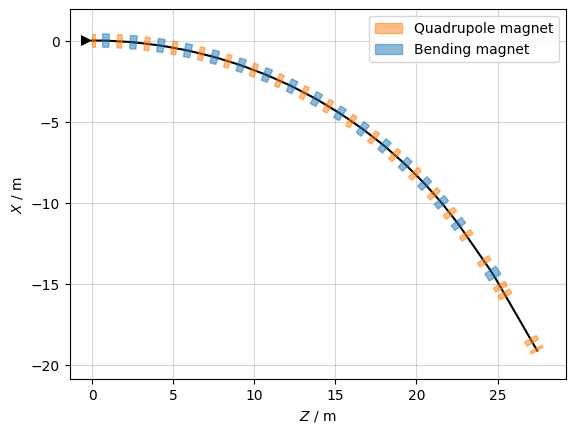

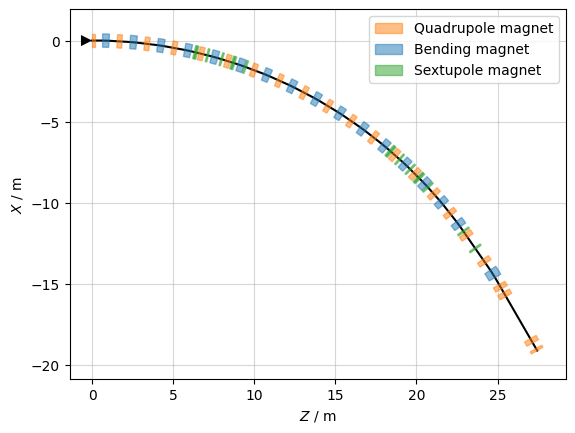

In [1519]:
#forming the arc and identifying sextupole positions
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )
arc1R.survey().plot()

sf_top,sd_top=SextupolePosition(arc1R)

new_elements=[]
for name, dx, betx, s in sf_top:
        if '_end_point' in name:
               continue
        elif 'Dr' in name:
                new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
        else:
                new_elements.append(pdr.place('SFDS', at=-0.3, from_=f'{name}@center'))

# 4. Automate SD insertions (e.g., 0.2m after the found element)
for name, dx, bety, s in sd_top:
        if '_end_point' in name:
               continue
        elif 'Dr' in name:
                new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
        else:        
          new_elements.append(pdr.place('SDDS', at=0.3, from_=f'{name}@center'))

arc1R.insert(new_elements)
arc1R.survey().plot()

In [1520]:
'''pdr['l_cell']=3.65

S1=makesextant( '1R', 'right') 
S2=makesextant( '2L', 'left') 
S3=makesextant( '2R', 'right') 
S4=makesextant( '3L', 'left') 
S5=makesextant( '3R', 'right') 
S6=makesextant( '1L', 'left')

sextants=[S1,S2,S3,S4,S5,S6]

for se in sextants:
        sf_top,sd_top=SextupolePosition(se)

        new_elements=[]
        for name, dx, betx, s in sf_top:
                if '_end_point' in name:
                 continue
                elif 'Dr' in name:
                        new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
                else:
                        continue
                        #new_elements.append(pdr.place('SFDS', at=-0.05, from_=f'{name}@start'))

        # 4. Automate SD insertions (e.g., 0.2m after the found element)
        
        for name, dx, bety, s in sd_top:
                if '_end_point' in name:
                        continue
                elif 'Dr' in name:
                                new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
                else:
                        continue        
                        #new_elements.append(pdr.place('SDDS', at=0.05, from_=f'{name}@end'))
        tt = se.get_table()
        print(tt.element_type)
        fig, ax = plt.subplots(figsize=(25,20))
        se.insert(new_elements)
        mask = np.isin(tt.element_type, ['Quadrupole', 'Bend'])
        #mask=tt.element_type=='Sextupole'
        se.survey().plot(labels=tt.name[mask],ax=ax)'''

        

"pdr['l_cell']=3.65\n\nS1=makesextant( '1R', 'right') \nS2=makesextant( '2L', 'left') \nS3=makesextant( '2R', 'right') \nS4=makesextant( '3L', 'left') \nS5=makesextant( '3R', 'right') \nS6=makesextant( '1L', 'left')\n\nsextants=[S1,S2,S3,S4,S5,S6]\n\nfor se in sextants:\n        sf_top,sd_top=SextupolePosition(se)\n\n        new_elements=[]\n        for name, dx, betx, s in sf_top:\n                if '_end_point' in name:\n                 continue\n                elif 'Dr' in name:\n                        new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))\n                else:\n                        continue\n                        #new_elements.append(pdr.place('SFDS', at=-0.05, from_=f'{name}@start'))\n\n        # 4. Automate SD insertions (e.g., 0.2m after the found element)\n\n        for name, dx, bety, s in sd_top:\n                if '_end_point' in name:\n                        continue\n                elif 'Dr' in name:\n                            

Slicing line: 100%|██████████| 88/88 [00:00<00:00, 205282.95it/s]


Successfully inserted for Line(mode=normal, 88 elements)


Slicing line: 100%|██████████| 88/88 [00:00<00:00, 202801.51it/s]


Successfully inserted for Line(mode=normal, 88 elements)


Slicing line: 100%|██████████| 88/88 [00:00<00:00, 180842.11it/s]


...

Successfully inserted for Line(mode=normal, 90 elements)


Slicing line: 100%|██████████| 88/88 [00:00<00:00, 108303.62it/s]


Successfully inserted for Line(mode=normal, 90 elements)


Slicing line: 100%|██████████| 88/88 [00:00<00:00, 113778.90it/s]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Successfully inserted for Line(mode=normal, 90 elements)


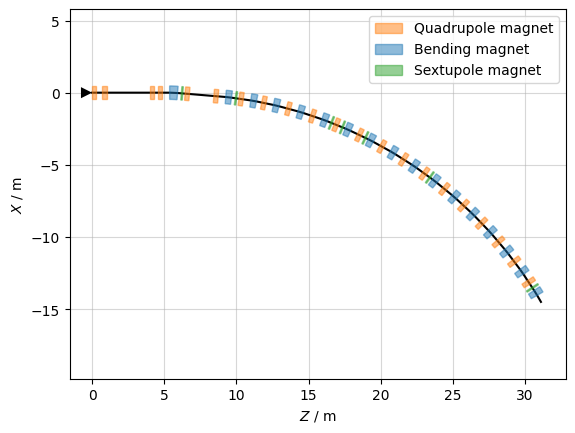

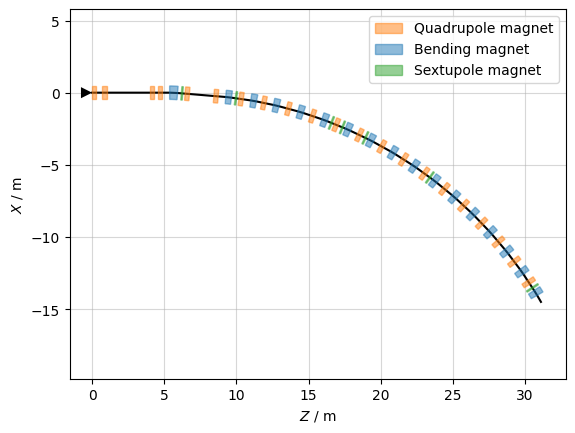

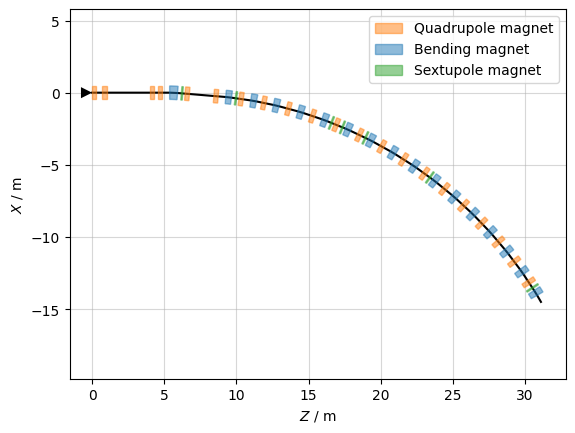

In [ ]:
pdr['l_cell']=3.4

S1=makesextant( '1R', 'right'); S1.tag = '1R'
S2=makesextant( '2L', 'left') ; S2.tag = '2L'
S3=makesextant( '2R', 'right') ; S3.tag = '2R'
S4=makesextant( '3L', 'left') ; S4.tag = '3L'
S5=makesextant( '3R', 'right') ; S5.tag = '3R'
S6=makesextant( '1L', 'left'); S6.tag = '1L'

right_sextants=[S1,S3,S5]
for sextant in right_sextants:
    # 1. Define the inserts with unique names manually or using a list
    tab1 = sextant.get_table()

    # 2. Define your drift offset (e.g., half of l_drift)
    # Since you're outside the function, you might need to use a number like 0.3
    drift_offset=pdr['l_drift']/2

    name = sextant.tag
    inserts_R = [
        {'name': f'SFDS1_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFA_{name}2'},
        {'name': f'SFDS2_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'Bend2_{name}6'},
        {'name': f'SFDS3_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFA_{name}5'},
        {'name': f'SFDS4_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFDS_{name}'},
        {'name': f'SDDS1_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'QDA_{name}2'},
        {'name': f'SDDS2_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'QDA_{name}6'},
        {'name': f'SDDS3_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'Bend2_{name}6'}
    ]

    for ins in inserts_R:
        anchor = ins['from']
        
        # Get the s-position of the anchor magnet from the table
        # tab1['s', anchor] gives the position of the START of the magnet
        # We add the magnet's length to get the position of its END
        
        pos_at_end = tab1.rows[anchor].s_end[0]+drift_offset

        # We grab the element object from the environment (pdr.elements)
        sextant.insert_element(
            name=ins['name'],
            element=pdr.elements[ins['type']],
            at_s=pos_at_end,
        )
    print('Successfully inserted for', sextant)
    sextant.survey().plot
    plt.show()

left_sextants=[S2,S4,S6]
for sextant in left_sextants:
    # 1. Define the inserts with unique names manually or using a list
    tab1 = sextant.get_table()

    # 2. Define your drift offset (e.g., half of l_drift)
    # Since you're outside the function, you might need to use a number like 0.3
    drift_offset = pdr['l_drift']/2 

    name = sextant.tag
    inserts_L = [
        {'name': f'SFDS1_{name}', 'type': 'SFDS', 'from': f'BendDS_{name}'},
        {'name': f'SFDS2_{name}', 'type': 'SFDS', 'from': f'QFA_{name}4'},
        {'name': f'SDDS1_{name}', 'type': 'SDDS', 'from': f'QDA_{name}4'},
        {'name': f'SDDS2_{name}', 'type': 'SDDS', 'from': f'QDA_{name}6'},
        {'name': f'SDDS3_{name}', 'type': 'SDDS', 'from': f'Bend2_{name}6'},
        {'name': f'SDDS4_{name}', 'type': 'SDDS', 'from': f'QDA_{name}1'},
        {'name': f'SDDS5_{name}', 'type': 'SDDS', 'from': f'Bend2_{name}8'}
    ]

    for ins in inserts_L:
        anchor = ins['from']
        if anchor not in tab1.name:
            print(f'Anchor {anchor} not found for sextant {name}')
        # Get the s-position of the anchor magnet from the table
        # tab1['s', anchor] gives the position of the START of the magnet
        # We add the magnet's length to get the position of its END
        
        pos_at_end = tab1.rows[anchor].s_end[0]+drift_offset

        # We grab the element object from the environment (pdr.elements)
        sextant.insert_element(
            name=ins['name'],
            element=pdr.elements[ins['type']],
            at_s=pos_at_end,
        )
    print('Successfully inserted for', sextant)
    sextant.survey().plot()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


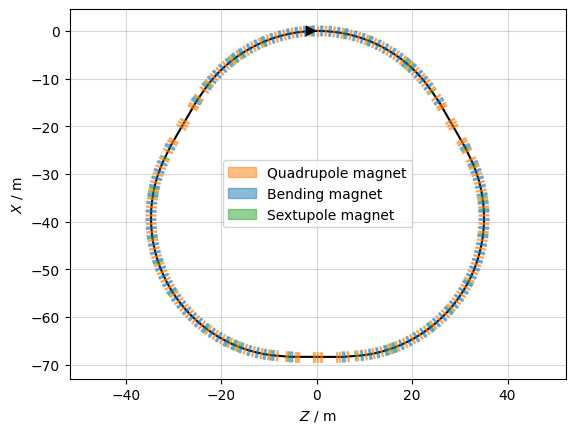

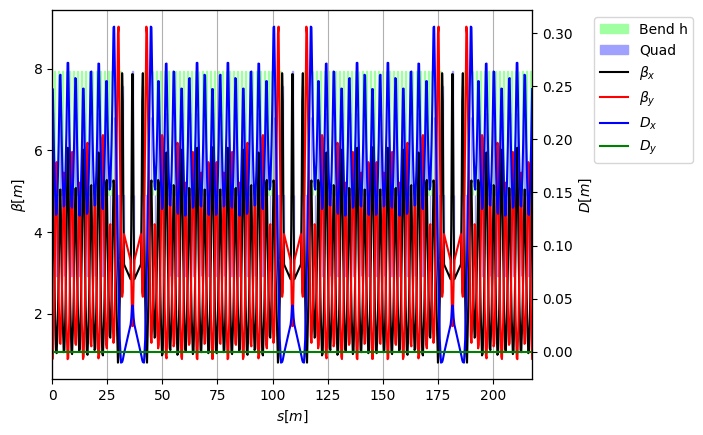

In [1522]:
ring=S1+S2+S3+S4+S5+S6
ring.survey().plot()

tw=ring.twiss4d()
tw.plot()

In [1523]:
def addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 ):
    fig, ax = plt.subplots( 3, 1, figsize=(12, 8), height_ratios=(1.8, 4, 3) )
    axl, axp, axt = ax
    axp.sharex( axl )
    fig.subplots_adjust( hspace=0.0, top=1.0, bottom=0.0, left=.1 )

    axp.set_xlabel( 'Position s [m]' )
    axp.set_ylim( limy1 )
    axp.set_ylabel( r'$\beta_x$, $\beta_y$ [m]' )
      
    indm = int( np.array([(np.sign(lims[-1]-x) + 1)/2 for x in acc_tw.s ]).sum() )
    axp.plot( acc_tw.s[:indm], acc_tw.betx[:indm], color='black', linestyle=(0, (10, 0)) )
    axp.plot( acc_tw.s[:indm], acc_tw.bety[:indm], color='black', linestyle=(0, (6, 4)) )
    axp2 = axp.twinx()
    axp2.set_ylim( limy2 )
    axp2.set_ylabel( r'$D_x$, $D_y$ [m]' )
    axp2.plot( acc_tw.s[:indm], acc_tw.dx[:indm], color='black', linestyle=(0, (5, 3, 1, 3)) )
    axp2.plot( acc_tw.s[:indm], acc_tw.dy[:indm] )
    axp.set_xlim( lims )
    
    axl.set_ylim( -.30, 1.00 )
    axl.axis( 'off' )
    tab_pan = acc.get_table(attr=True).to_pandas()
    for ind in range( len(tab_pan.T.columns) -1 ):
        if tab_pan['element_type'][ind].find('Drift') >= 0:
           axl.plot( [tab_pan['s'][ind], tab_pan['s'][ind+1]], [0, 0], color='black' )
        if tab_pan['element_type'][ind].find('Bend') >= 0:
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], -0.08), 
               tab_pan['s'][ind+1] - tab_pan['s'][ind], 0.16, fill=True, color='tab:blue' ) ) 
        if tab_pan['element_type'][ind].find('Quad') >= 0:
           kstr = scK1*tab_pan['k1l'][ind]/tab_pan['length'][ind]
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], min(0.0, kstr)),
               tab_pan['s'][ind+1] - tab_pan['s'][ind], abs(kstr), fill=True, color='tab:orange' ) )        
        if tab_pan['element_type'][ind].find('Sext')>=0:
           axl.add_patch( patches.Rectangle( (tab_pan['s'][ind], -0.06), 
               tab_pan['s'][ind+1] - tab_pan['s'][ind], 0.12, fill=True, color='tab:green' ) ) 
    axp.plot( [acc.get_length(), acc.get_length()], limy1, color='black', 
              linestyle=(0, (8, 8)), linewidth=.5 )

    axt.axis( 'off' )
    axt.set_xlim( -.3, 3.8 ); axt.set_ylim( 0, 1 )
    return axt

# Routine generating graphical and text output describing the ring    
def SpuckParsAus( acc_tw, acc, lims, limy1, limy2, scK1, grname='NoGraph' ):
    axt = addSketchBL( acc_tw, acc, lims, limy1, limy2, scK1 )
    axt.text( 0.0, .7, f'C ={3*acc_tw.circumference:8.4f} m', horizontalalignment='left' )
    axt.text( 1.0, .7, f'T ={3e6*acc_tw.T_rev0:8.4f} us', horizontalalignment='left')
    axt.text( 2.0, .7, r'($Q_x$, $Q_y$)' + f' = ({3*acc_tw.qx:9.5f}, {3*acc_tw.qy:9.5f})', 
        horizontalalignment='left')
    pos=0
    for item in pdr.vars.keys()[2:]:
       print( "'" + item + f"': {pdr[item]:8.4f}," )
       axt.text( pos%4 , .6 - .1*int( pos/4 ),
          "'" + item + f"': {pdr[item]:8.4f},", horizontalalignment='left' )
       pos += 1
    if grname != 'NoGraph': 
       if grname in os.listdir( '/home/mwatson/Documents/laughing-octo-bassoon'):
          print( ' Error: file ' + grname + ' exists <<<<<<<<<<<================' )
       else:
          plt.savefig( '/home/mwatson/Documents/laughing-octo-bassoon' + grname )
    tab_pan = acc.get_table(attr=True).to_pandas()
    print('  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)')
    for ind in range( len(tab_pan.T.columns) - 1 ):
       eltyp = tab_pan['element_type'][ind]
       if eltyp.find('Drift') < 0:
          elnam = tab_pan['name'][ind]
          if ind < 1: sin = '  0.0000'
          else: sin = f"{tab_pan['length'][ind-1]:8.4f}"         
          k1expr = pdr.element_refs[elnam].k1._expr
          if k1expr == None: k1expr = ' None'
          else: k1expr = str(k1expr)[5:-1]
          print(  "  " + elnam.ljust( 12 ) + eltyp.ljust(12)[:8] + f" {tab_pan['length'][ind]:7.4f} " + 
               f"{tab_pan['s'][ind]:8.4f} {tab_pan['s'][ind+1]:8.4f} " + sin +
               f"{tab_pan['length'][ind+1]:8.4f} " + k1expr.ljust(9) + 
               f"= {tab_pan['k1l'][ind]/max(tab_pan['length'][ind],1e-6):7.4f}  " )


Slicing line: 100%|██████████| 88/88 [00:00<00:00, 158683.90it/s]


Successfully inserted for Line(mode=normal, 88 elements)


Slicing line: 100%|██████████| 88/88 [00:00<00:00, 144461.35it/s]


Successfully inserted for Line(mode=normal, 90 elements)


Slicing line: 100%|██████████| 178/178 [00:00<00:00, 4161.55it/s]
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.9478,
'kQDarc':  -2.9231,
'kQFarcM':   2.8846,
'kQDarcM':  -2.7567,
'kQFDS':   2.8042,
'kQDDS':  -2.2858,
'kQFDoub':   3.9170,
'kQDDoub':  -2.5190,
'kQFtr':   4.4429,
'kQDtr':  -2.4723,
'l_sext':   0.1000,
'kSF':   0.0000,
'kSD':   0.0000,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRC     Quadrupo  0.3000   0.0000   0.3000   0.0000  0.5250 'kQFarc' =  2.9478  
  Bend1_PR1   Bend      0.4000   0.8250   1.2250   0.5250  0.5250  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.7500   2.0500   0.5250  0.5250 'kQDarc' = -2.9231  
  Bend2_PR1   Bend      0.4000   2.5750   2.9750   0.5250  0.5250  None    =  0.0000  
  QFA_PR0     Quadrupo  0.3000   3.5000   3.80

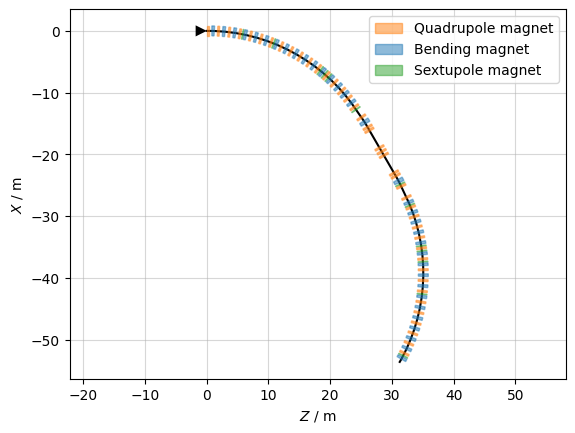

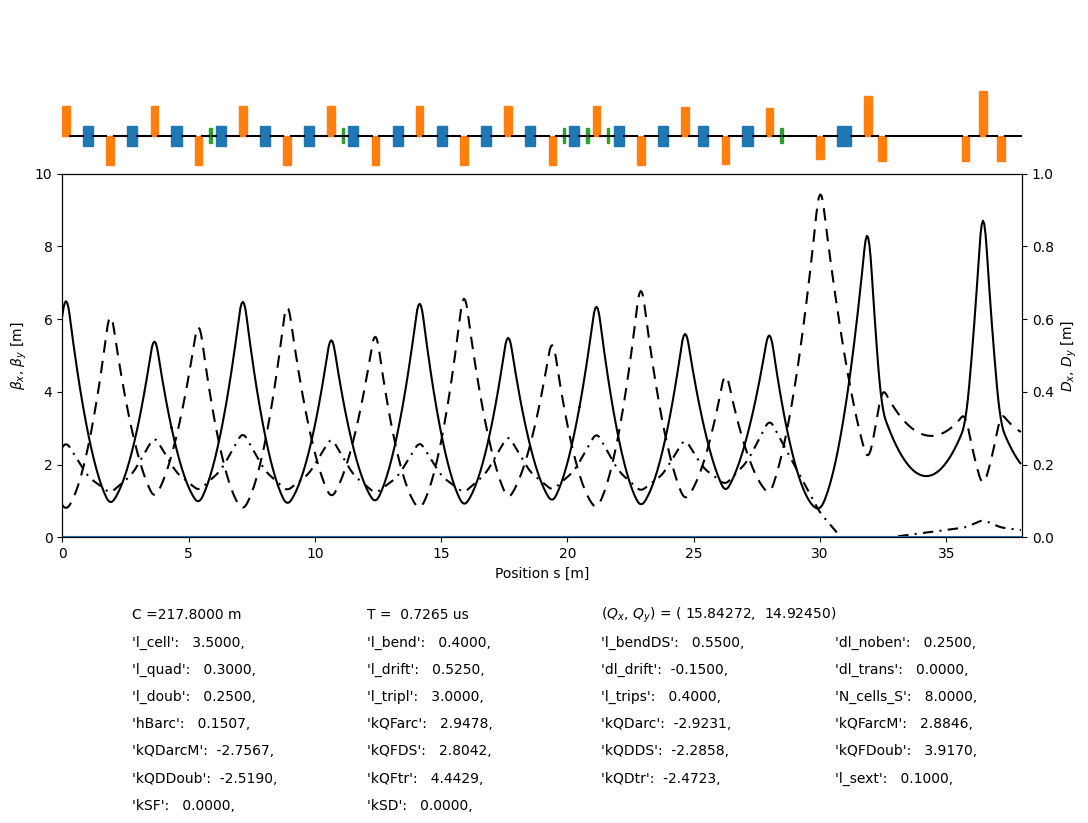

In [1524]:
PR=makesextant( 'PR', 'right'); tag='PR'
tab1 = PR.get_table()

    # 2. Define your drift offset (e.g., half of l_drift)
    # Since you're outside the function, you might need to use a number like 0.3
drift_offset=pdr['l_drift']/2

name = 'PR'
inserts_R = [
        {'name': f'SFDS1_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFA_{name}2'},
        {'name': f'SFDS2_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'Bend2_{name}6'},
        {'name': f'SFDS3_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFA_{name}5'},
        {'name': f'SFDS4_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFDS_{name}'},
        {'name': f'SDDS1_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'QDA_{name}2'},
        {'name': f'SDDS2_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'QDA_{name}6'},
        {'name': f'SDDS3_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'Bend2_{name}6'}
    ]


for ins in inserts_R:
        anchor = ins['from']
        
        # Get the s-position of the anchor magnet from the table
        # tab1['s', anchor] gives the position of the START of the magnet
        # We add the magnet's length to get the position of its END
        
        pos_at_end = tab1.rows[anchor].s_end[0]+drift_offset

        # We grab the element object from the environment (pdr.elements)
        PR.insert_element(
            name=ins['name'],
            element=pdr.elements[ins['type']],
            at_s=pos_at_end,
        )
print('Successfully inserted for', PR)


PL=makesextant( 'PL', 'left'); tag='PL'

tab1 = PL.get_table()

    # 2. Define your drift offset (e.g., half of l_drift)
    # Since you're outside the function, you might need to use a number like 0.3
drift_offset = pdr['l_drift']/2

name = 'PL'
inserts_L = [
        {'name': f'SFDS1_{name}', 'type': 'SFDS', 'from': f'BendDS_{name}'},
        {'name': f'SFDS2_{name}', 'type': 'SFDS', 'from': f'QFA_{name}4'},
        {'name': f'SDDS1_{name}', 'type': 'SDDS', 'from': f'QDA_{name}4'},
        {'name': f'SDDS2_{name}', 'type': 'SDDS', 'from': f'QDA_{name}6'},
        {'name': f'SDDS3_{name}', 'type': 'SDDS', 'from': f'Bend2_{name}6'},
        {'name': f'SDDS4_{name}', 'type': 'SDDS', 'from': f'QDA_{name}1'},
        {'name': f'SDDS5_{name}', 'type': 'SDDS', 'from': f'Bend2_{name}8'}
    ]
for ins in inserts_L:
        anchor = ins['from']
        if anchor not in tab1.name:
            print(f'Anchor {anchor} not found for sextant {name}')
        # Get the s-position of the anchor magnet from the table
        # tab1['s', anchor] gives the position of the START of the magnet
        # We add the magnet's length to get the position of its END
        
        pos_at_end = tab1.rows[anchor].s_end[0]+drift_offset

        # We grab the element object from the environment (pdr.elements)
        PL.insert_element(
            name=ins['name'],
            element=pdr.elements[ins['type']],
            at_s=pos_at_end,
        )
print('Successfully inserted for', PL)

period = PR+PL
period.survey().plot()
period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )
SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )

Target status:               alty = 2.8476e+01              
id state tag tol_met       residue   current_val    target_val description                      
0  ON    dqx   False      -21.1002      -21.1002             0 'dqx', val=0, tol=0.001, weight=1
1  ON    dqy   False      -19.1227      -19.1227             0 'dqy', val=0, tol=0.001, weight=1
Target status:               nalty = 3.1481e-04              
id state tag tol_met       residue   current_val    target_val description                      
0  ON    dqx    True   0.000314807   0.000314807             0 'dqx', val=0, tol=0.001, weight=1
1  ON    dqy    True   6.78213e-08   6.78213e-08             0 'dqy', val=0, tol=0.001, weight=1
Matched kSF: 596.988851
Matched kSD: -457.335985
'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   

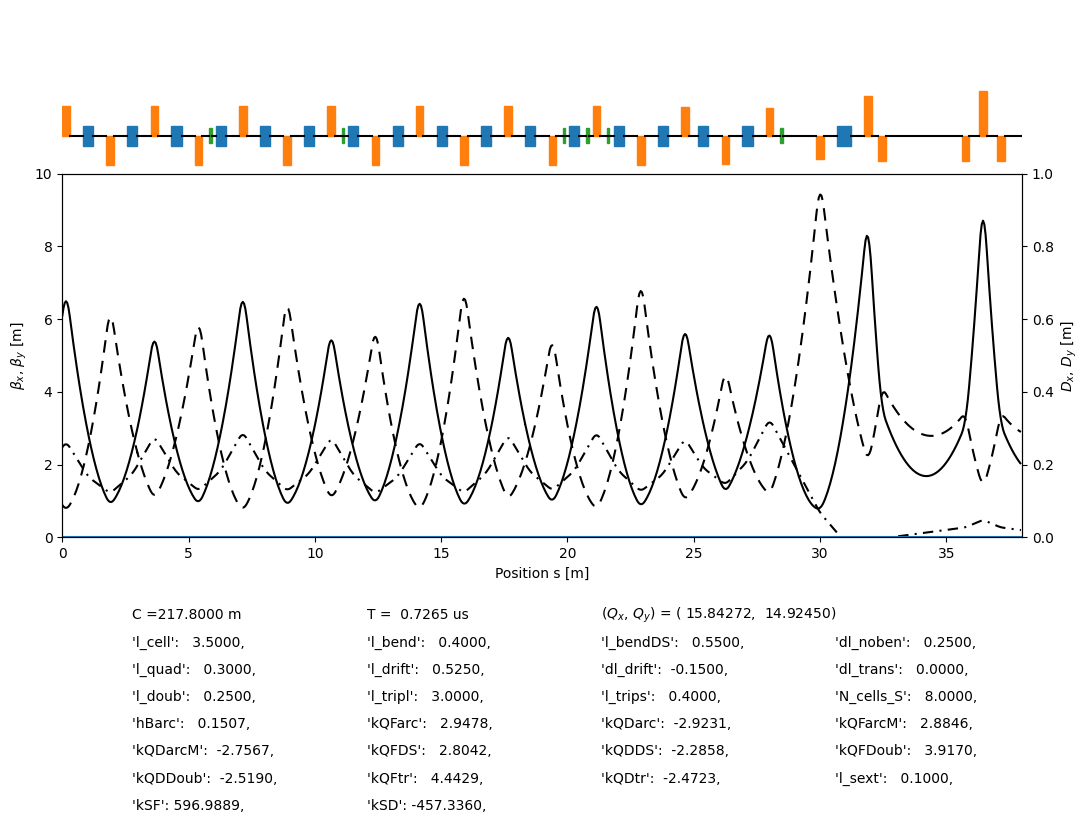

In [1525]:
def ChromCorrect(ksf, ksd, MakePlot=False):
        
    opt_chrom = ring.match(
        solve=False,
        verbose=False,
        method='4d',
        vary=xt.VaryList([ksf, ksd], step=1e-3),
        targets=xt.TargetSet(dqx=0., dqy=0., tol=1e-3))
    opt_chrom.target_status()
    opt_chrom.run_jacobian(n_steps=100)
    opt_chrom.target_status()
    # Print the final matched strengths

    print(f"Matched kSF: {pdr.vars['kSF']._get_value():.6f}")
    print(f"Matched kSD: {pdr.vars['kSD']._get_value():.6f}")   

ChromCorrect('kSF', 'kSD')

SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )

Slicing line: 100%|██████████| 534/534 [00:00<00:00, 264559.22it/s]


Horizontal Chromaticity (dqx): 0.0115
Vertical Chromaticity (dqy):   0.1596
Max Betx: 7.98 m
Max Bety: 9.20 m


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.



Approximatif harmonics  291.00000 and fRF =400549145.48213
  Length of short drifts:   0.525 m
=>Circumference 217.8000 and revolution  0.72650 us
  Energy loss per turn from me  891804.40 and twiss   892439.35 and diff     634.95
  Vertical damping time   6410.603 and   6409.399 turns
  Working point  15.84205 and  14.92504
  Equilibrium emmittances 2.716e-08, 4.418e-52 and 1.265e-05
  Equilibrium polarization 0.92376 and time     786.53 s


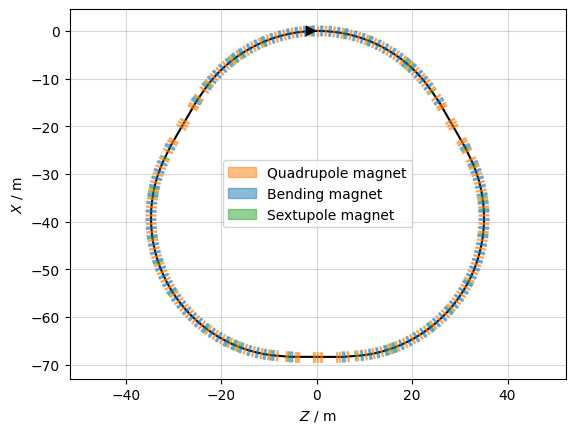

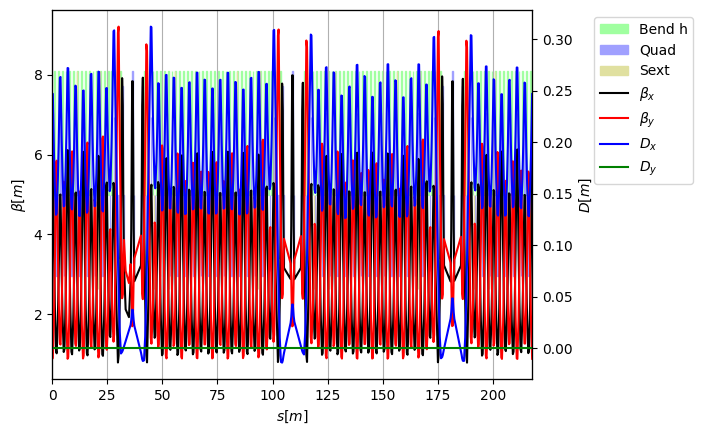

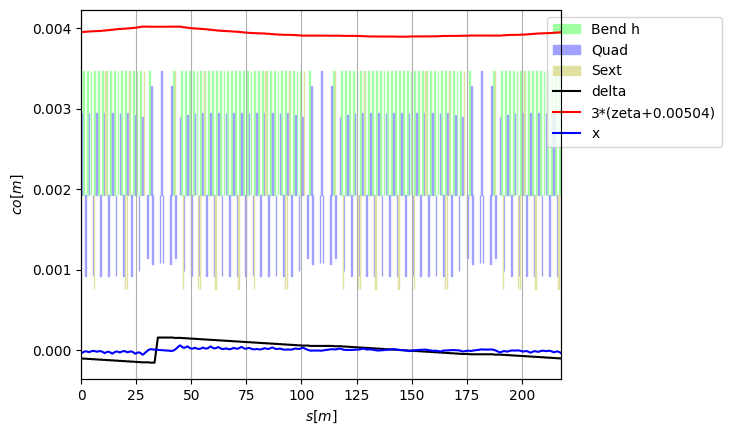

In [1526]:
fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz
pdr.new('RFCav',  xt.Cavity, length=1.5, frequency=fRF, voltage=VRF, 
        lag=(180/np.pi)*(np.pi - np.arcsin(U0/VRF)) - 1.8 ) 
ring.insert( pdr.new('RFCav_1', 'RFCav'), at='(l_tripl+l_quad)/2', from_='QDDoub_1R' )
ring.configure_radiation(model='mean')
ring.configure_bend_model(edge='full')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )
print(f"Horizontal Chromaticity (dqx): {ring_tw.dqx:.4f}")
print(f"Vertical Chromaticity (dqy):   {ring_tw.dqy:.4f}")
print(f"Max Betx: {max(ring_tw.betx):.2f} m")
print(f"Max Bety: {max(ring_tw.bety):.2f} m")

ring.survey().plot()

ring_tw.plot()
ring_tw.plot('delta 3*(zeta+0.00504) x')

print( f'\nApproximatif harmonics {fRF/fRev:10.5f} and fRF ={fRF:8.5f}' )
# print( ring_tw.keys() )
print( f"  Length of short drifts: {pdr['l_drift']:7.3f} m" )
# print( ring_tw.keys() )
print( f'=>Circumference {ring_tw.circumference:8.4f} and revolution {1e6*ring_tw.T_rev0:8.5f} us' )
print( f'  Energy loss per turn from me {U0:10.2f} and twiss' + 
       f'  {ring_tw.eneloss_turn:10.2f} and diff {ring_tw.eneloss_turn-U0:10.2f}' )
print( f'  Vertical damping time {1/ring_tw.damping_constants_turns[1]:10.3f} and {2*E0/ring_tw.eneloss_turn:10.3f} turns' )
print( f'  Working point{ring_tw.qx:10.5f} and{ring_tw.qy:10.5f}')
print( f'  Equilibrium emmittances{ring_tw.eq_gemitt_x:10.3e},{ring_tw.eq_gemitt_y:10.3e} and{ring_tw.eq_gemitt_zeta:10.3e}'  )
print( f'  Equilibrium polarization{ring_tw.spin_polarization_eq:8.5f} and time {ring_tw.spin_t_pol_buildup_s:10.2f} s')

In [1527]:
# %% Routine for several matchings in a row for 90 degrees arc cells and given tunes

# Matching of arc cell
cell_arc_opt = cell_arc.match( method='4d', solve=False, verbose=False,
    vary=[
        xt.VaryList(['kQFarc', 'kQDarc'], step=1e-4),    ],
    targets=[
        xt.TargetSet(qx=0.25, qy=0.25, tol=1.0e-6, tag='end'), # just twice the same 
        xt.TargetSet(mux=0.25, muy=0.25, at=xt.END, tol=1.0e-6)]  )
print(f"Matched kQFarc: {pdr.vars['kQFarc']._get_value():.6f}")
print(f"Matched kQDarc: {pdr.vars['kQDarc']._get_value():.6f}")   

# Triplet cell to chosen betatron functions
cell_tr_opt = cell_tr.match( method='4d', solve=False,
    vary=[ # use individual Vary commands instead of List for arc cell
        xt.Vary('kQFtr', step=1e-4 ),
        xt.Vary('kQDtr', step=1e-4),    ],
    targets=[
        xt.TargetSet(betx=2.50, bety=2.50, at='Mkr_cell_tr', tol=1.0e-6, tag='betas')] )
print(f"Matched kQFtr: {pdr.vars['kQFtr']._get_value():.6f}")
print(f"Matched kQDtr: {pdr.vars['kQDtr']._get_value():.6f}")   

'''# Matching sequence with ring working as (one of the) target(s)
def matchingWP( qx, qy, MakePlot=False ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    arc1R_opttune = arc1R.match( method='4d', solve=False, verbose=False,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4),
                   xt.VaryList(['kQFtr', 'kQDtr'], step=1e-4), ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(mux=qx/6, muy=qy/6, at=xt.END, 
                                   tol=1.0e-9, weight=.1, tag='phase'),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at='CtrS1_xR1', 
                                   tol=1.0e-9, weight=10.) ])
    arc1R_opttune.run_jacobian(50)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() 
        
# Matching sequence for sextant with beta at center of straights fixed
def matchingBeta( betxS, betyS, MakePlot=False ): #, **kwargs ):
    cell_arc_opt.run_jacobian(10)
    cell_arc_tw = cell_arc.twiss( method='4d' )
    cell_tr_opt.targets[0].value, cell_tr_opt.targets[1].value = betxS, betyS
    cell_tr_opt.run_jacobian(10)
    cell_tr_tw = cell_tr.twiss( method='4d' )
    arc1R_opt = arc1R.match( method='4d', solve=False,
                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],
            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),
                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),
                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4) ],
            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(alfx=0, alfy=0, at=xt.END, tol=1.0e-9),
                      xt.TargetSet(betx=cell_tr_tw.betx[0], bety=cell_tr_tw.bety[0],
                                   at=xt.END, tol=1.0e-9) ])
    arc1R_opt.run_jacobian(10)
    if MakePlot:
       arc1R.twiss( method='4d',
                    betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],
                    bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],
                    dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],).plot() '''


Matched kQFarc: 2.947800
Matched kQDarc: -2.923100
Matched kQFtr: 4.442900
Matched kQDtr: -2.472300


"# Matching sequence with ring working as (one of the) target(s)\ndef matchingWP( qx, qy, MakePlot=False ):\n    cell_arc_opt.run_jacobian(10)\n    cell_arc_tw = cell_arc.twiss( method='4d' )\n    arc1R_opttune = arc1R.match( method='4d', solve=False, verbose=False,\n                 betx=cell_arc_tw.betx[0], alfx=cell_arc_tw.alfx[0],\n                 bety=cell_arc_tw.bety[0], alfy=cell_arc_tw.alfy[0],\n                 dx=cell_arc_tw.dx[0],     dpx=cell_arc_tw.dpx[0],\n            vary=[ xt.VaryList(['kQFarcM', 'kQDarcM'], step=1e-4),\n                   xt.VaryList(['kQFDS', 'kQDDS'], step=1e-4),\n                   xt.VaryList(['kQFDoub', 'kQDDoub'], step=1e-4),\n                   xt.VaryList(['kQFtr', 'kQDtr'], step=1e-4), ],\n            targets=[ xt.TargetSet(dx=0, dpx=0, at=xt.END, tol=1.0e-9),\n                      xt.TargetSet(mux=qx/6, muy=qy/6, at=xt.END, \n                                   tol=1.0e-9, weight=.1, tag='phase'),\n                      xt.TargetSet(alfx=0, 